<a href="https://colab.research.google.com/github/aurora1112-j/aurora1112-j.github.io/blob/main/security_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Matrix Shape: (149, 149)


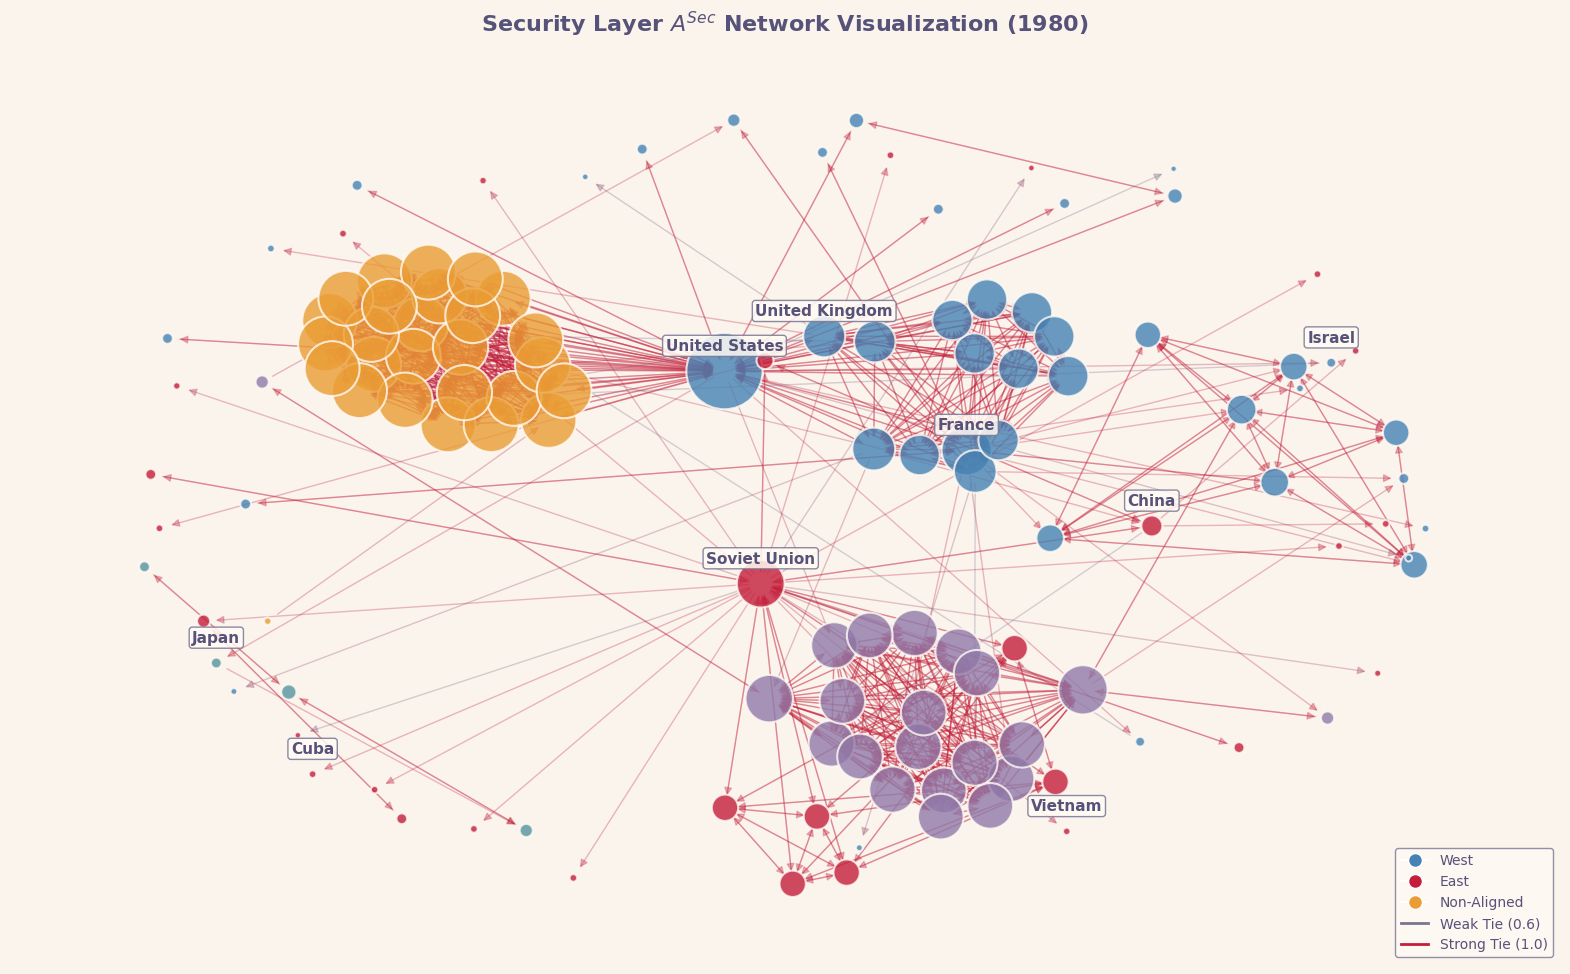

In [28]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from networkx.algorithms.community import greedy_modularity_communities

# --- Rose-Pine Dawn 配色定义 ---
rose_pine_dawn = {
    'base': '#faf4ed',    # 背景色
    'surface': '#fffaf3', # 节点描边/标签背景
    'text': '#575279',    # 主要文字
    'muted': '#9893a5',   # 弱边颜色
    'subtle': '#797593',  # 中等边颜色
    'red': '#C41E3A',    # 强边/核心阵营1 (红色系)
    'blue': '#4682B4',    # 核心阵营2 (蓝绿色系)
    'gold': '#ea9d34',    # 外围阵营 (黄色系)
    'iris': '#907aa9',    # 其他
    'foam': '#56949f'     # 其他
}

# 1. 读取数据
df = pd.read_csv('name_to_cow.csv')

# 2. 筛选年份 (以 1980 年为例)
YEAR = 1980
df_year = df[df['year'] == YEAR]

# 3. 构建矩阵 A_sec
# 使用 pivot 方法将长表转换为宽表 (Matrix)
# 行索引=施加方(stateA), 列索引=接受方(stateB), 值=权重
nodes = sorted(list(set(df_year['stateA']) | set(df_year['stateB'])))
matrix_df = df_year.pivot(index='stateA', columns='stateB', values='final_security_weight')

# 填充缺失值 (NaN -> 0) 并确保是方阵 (Square Matrix)
matrix_df = matrix_df.reindex(index=nodes, columns=nodes, fill_value=0)
matrix_df = matrix_df.fillna(0)

# 获取 numpy 矩阵形式，用于后续代数运算
A_sec = matrix_df.values
print(f"Matrix Shape: {A_sec.shape}")  # 输出: (149, 149)

# 从矩阵生成图
G = nx.from_pandas_adjacency(matrix_df, create_using=nx.DiGraph)



# --- 4. 筛选与网络分析 ---
THRESHOLD = 0.6
# 仅保留强连接用于绘图 (数学计算仍使用完整矩阵 A_sec)
edges_to_keep = [(u, v) for u, v, d in G.edges(data=True) if d['weight'] > THRESHOLD]
G_plot = G.edge_subgraph(edges_to_keep).copy()
G_plot.remove_edges_from(nx.selfloop_edges(G_plot)) # 移除自环以防报错
G_plot.remove_nodes_from(list(nx.isolates(G_plot))) # 移除孤立点

# 社区发现 (用于给节点上色)
communities = list(greedy_modularity_communities(G_plot))
# 将社区映射到 Rose-Pine 颜色
comm_palette = [rose_pine_dawn['blue'], rose_pine_dawn['red'], rose_pine_dawn['gold'],
                rose_pine_dawn['iris'], rose_pine_dawn['foam']]
node_color_map = {}
for i, comm in enumerate(communities):
    c = comm_palette[i % len(comm_palette)]
    for n in comm:
        node_color_map[n] = c
node_colors = [node_color_map.get(n, rose_pine_dawn['muted']) for n in G_plot.nodes()]

# 节点大小 (基于度中心性)
degrees = dict(G_plot.degree(weight='weight'))
node_sizes = [degrees[n] * 30 for n in G_plot.nodes()]

# 布局计算
pos = nx.spring_layout(G_plot, k=0.7, seed=42, weight='weight')

# --- 4. 绘图 (应用配色) ---
plt.figure(figsize=(20, 12), facecolor=rose_pine_dawn['base'])
ax = plt.gca()
ax.set_facecolor(rose_pine_dawn['base'])

# A. 绘制边 (渐变色)
edge_weights = [d['weight'] for u, v, d in G_plot.edges(data=True)]
# 创建自定义渐变色板: Muted -> Love
cmap_edges = LinearSegmentedColormap.from_list('rose_pine_edges',
                                              [rose_pine_dawn['subtle'], rose_pine_dawn['red']])

nx.draw_networkx_edges(
    G_plot, pos,
    edge_color=edge_weights,
    edge_cmap=cmap_edges,
    edge_vmin=0.6, edge_vmax=1.0, # 映射范围
    width=1,
    alpha=0.3,
    arrows=True,
    arrowstyle='-|>', arrowsize=12
)

# B. 绘制节点
nx.draw_networkx_nodes(
    G_plot, pos,
    node_size=node_sizes,
    node_color=node_colors,
    edgecolors=rose_pine_dawn['surface'], # 节点白边
    alpha=0.8,
    linewidths=1.5
)

# C. 绘制标签 (Top 15)
# 反转映射字典
cow_to_name = {
   # --- North America ---
    2: "United States", 20: "Canada",    31: "Bahamas",    40: "Cuba",
    41: "Haiti",    42: "Dominican Republic",    51: "Jamaica",    52: "Trinidad and Tobago",
    53: "Barbados",    70: "Mexico",    80: "Belize",    90: "Guatemala",
    91: "Honduras",    92: "El Salvador",    93: "Nicaragua",    94: "Costa Rica",
    95: "Panama",

    # --- South America ---
    100: "Colombia",    101: "Venezuela",    110: "Guyana",    115: "Suriname",
    130: "Ecuador",    135: "Peru",    140: "Brazil",    145: "Bolivia",
    150: "Paraguay",    155: "Chile",    160: "Argentina",    165: "Uruguay",

    # --- Europe ---
    200: "United Kingdom",    205: "Ireland",    210: "Netherlands",
    211: "Belgium",    212: "Luxembourg",    220: "France",    225: "Switzerland",
    230: "Spain",    235: "Portugal",    260: "Germany (FRG)",  # Explicitly West Germany
    265: "East Germany (GDR)",    290: "Poland",    305: "Austria",
    310: "Hungary",    315: "Czechoslovakia",    325: "Italy",    338: "Malta",
    339: "Albania",    345: "Yugoslavia",    350: "Greece",    352: "Cyprus",
    355: "Bulgaria",    360: "Romania",
    365: "Soviet Union",   # Covers Russia for this period
    375: "Finland",    380: "Sweden",    385: "Norway",
    390: "Denmark",    395: "Iceland",    640: "Turkey",

    # --- Africa ---
    402: "Cape Verde",    403: "Sao Tome and Principe",    404: "Guinea-Bissau",
    411: "Equatorial Guinea",    420: "Gambia",    432: "Mali",
    433: "Senegal",    434: "Benin",    435: "Mauritania",
    436: "Niger",    437: "Cote d'Ivoire",    438: "Guinea",
    439: "Burkina Faso",    450: "Liberia",    451: "Sierra Leone",
    452: "Ghana",    461: "Togo",    471: "Cameroon",
    475: "Nigeria",    481: "Gabon",    482: "Central African Republic",
    483: "Chad",    484: "Congo",    490: "DR Congo",    500: "Uganda",
       501: "Kenya",    510: "Tanzania",
    516: "Burundi",    517: "Rwanda",    520: "Somalia",
    522: "Djibouti",    530: "Ethiopia",    540: "Angola",
    541: "Mozambique",    551: "Zambia",    552: "Zimbabwe",
    553: "Malawi",    560: "South Africa",    565: "Namibia",
    570: "Lesotho",    571: "Botswana",    572: "eSwatini",
    580: "Madagascar",    581: "Comoros",    590: "Mauritius",
    591: "Seychelles",    600: "Morocco",    615: "Algeria",
    616: "Tunisia",    620: "Libya",    625: "Sudan",

    # --- Middle East ---
    630: "Iran",    645: "Iraq",    651: "Egypt",
    652: "Syria",    660: "Lebanon",    663: "Jordan",
    666: "Israel",    670: "Saudi Arabia",    678: "Yemen (North)",
    680: "South Yemen",    690: "Kuwait",    692: "Bahrain",    694: "Qatar",
    696: "UAE",    698: "Oman",

    # --- Asia ---
    700: "Afghanistan",    710: "China",    712: "Mongolia",    713: "Taiwan",
    731: "North Korea",    732: "South Korea",    740: "Japan",    750: "India",
    760: "Bhutan",    770: "Pakistan",    771: "Bangladesh",   775: "Myanmar",
    780: "Sri Lanka",    790: "Nepal",    800: "Thailand",    811: "Cambodia",
    812: "Laos",    816: "Vietnam",    817: "South Vietnam",    820: "Malaysia",
    830: "Singapore",    835: "Brunei",    840: "Philippines",    850: "Indonesia",
    900: "Australia",    910: "Papua New Guinea",    920: "New Zealand",
    935: "Vanuatu",    940: "Solomon Islands",    950: "Fiji",    955: "Tonga"
}

# 选取指定的国家
target_countries = [
    "United States", "Soviet Union", "China",
    "United Kingdom", "France", "West Germany",
    "Japan", "Israel", "Vietnam", "Cuba"
]
# 生成标签字典
labels = {}
for node in G_plot.nodes():
    # 获取节点的国家名
    country_name = cow_to_name.get(node)

    # 如果名字名单里，就加标签
    if country_name in target_countries:
        labels[node] = country_name



for n, label in labels.items():
    if n in pos:
        x, y = pos[n]
        plt.text(x, y+0.045, label,
                 fontsize=11, fontweight='bold', color=rose_pine_dawn['text'],
                 ha='center', va='bottom',
                 bbox=dict(boxstyle="round,pad=0.2", fc=rose_pine_dawn['surface'],
                           ec=rose_pine_dawn['subtle'], alpha=0.85))

# D. 装饰
plt.title(f"Security Layer $A^{{Sec}}$ Network Visualization (1980)",
          fontsize=16, color=rose_pine_dawn['text'], fontweight='bold')

# 自定义图例
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='West', markerfacecolor=rose_pine_dawn['blue'], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='East', markerfacecolor=rose_pine_dawn['red'], markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Non-Aligned', markerfacecolor=rose_pine_dawn['gold'], markersize=10),
    Line2D([0], [0], color=rose_pine_dawn['subtle'], lw=2, label='Weak Tie (0.6)'),
    Line2D([0], [0], color=rose_pine_dawn['red'], lw=2, label='Strong Tie (1.0)'),
]
leg = plt.legend(handles=legend_elements, loc='lower right', frameon=True,
                 facecolor=rose_pine_dawn['surface'], edgecolor=rose_pine_dawn['subtle'])
for text in leg.get_texts():
    text.set_color(rose_pine_dawn['text'])

plt.axis('off')
plt.show()
